In [2]:
!pip install plotext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.8/475.8 kB 7.4 MB/s eta 0:00:00


Step 1: Generating synthetic flight session dataset...
  4000 sessions generated | features: ['rms_deviation', 'gyro_variability', 'correction_magnitude', 'oscillation_freq', 'settling_time', 'energy_cost']

Step 4: Training + 5-fold cross-validating each model...

Step 5: Model comparison (sorted by test MAE, lower is better)

            Model  CV_MAE_mean  CV_MAE_std  Test_MAE  Test_RMSE  Test_R2
Linear Regression        1.611       0.035     1.667      2.081    0.989
 Ridge Regression        1.611       0.035     1.667      2.081    0.989
              SVR        1.646       0.047     1.682      2.105    0.988
    Random Forest        1.842       0.077     1.896      2.376    0.985

Feature Importance (Random Forest)
  correction_magnitude  : 0.8880
  gyro_variability      : 0.0413
  energy_cost           : 0.0407
  rms_deviation         : 0.0214
  settling_time         : 0.0059
  oscillation_freq      : 0.0026


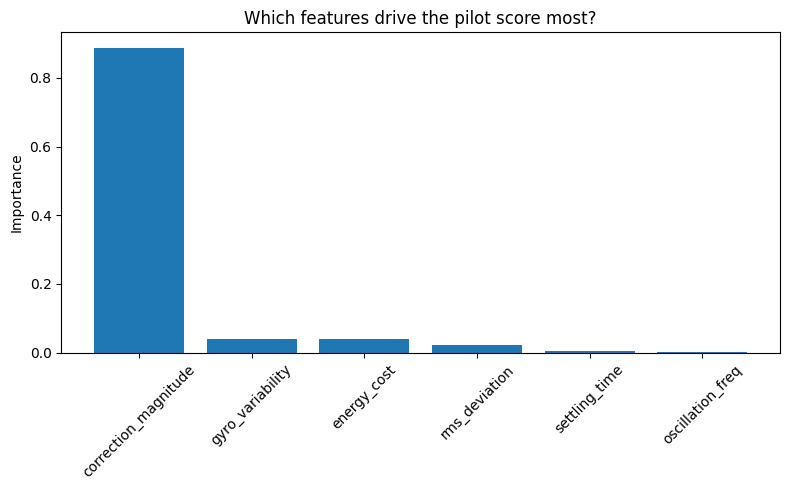


Residual Analysis — Linear Regression
  Mean residual : 0.065  (should be close to 0)
  Std residual  : 2.080
  Max abs error : 6.919



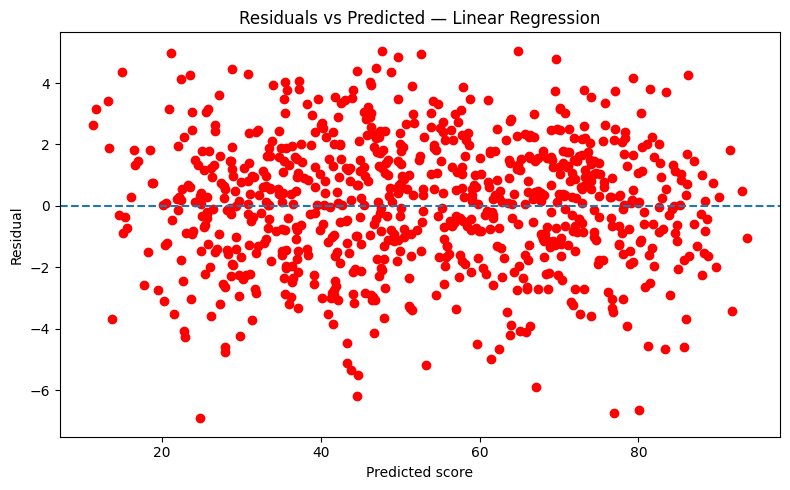


SAMPLE INPUTS: multiple unseen flight sessions

Pilot: skill=beginner (0.20), difficulty=easy (0.20)  | true score = 38.79
  Linear Regression   : predicted =  38.79  (abs error =  0.00)
  Ridge Regression    : predicted =  38.78  (abs error =  0.01)
  SVR                 : predicted =  39.20  (abs error =  0.40)
  Random Forest       : predicted =  40.56  (abs error =  1.77)

Pilot: skill=intermediate (0.55), difficulty=medium (0.50)  | true score = 60.74
  Linear Regression   : predicted =  60.62  (abs error =  0.12)
  Ridge Regression    : predicted =  60.62  (abs error =  0.12)
  SVR                 : predicted =  60.69  (abs error =  0.05)
  Random Forest       : predicted =  60.17  (abs error =  0.57)

Pilot: skill=advanced (0.85), difficulty=hard (0.80)  | true score = 69.80
  Linear Regression   : predicted =  69.73  (abs error =  0.06)
  Ridge Regression    : predicted =  69.73  (abs error =  0.06)
  SVR                 : predicted =  69.93  (abs error =  0.14)
  Random Fores

In [12]:
"""
AutoScore — Model Training & Evaluation (Improved)
----------------------------------------------------
Improvements over the base version:
  1. Adds R^2 and RMSE alongside MAE (MAE alone doesn't show how well
     variance in the score is explained).
  2. 5-fold cross-validation on the training set, so the reported
     performance isn't dependent on a single lucky/unlucky split.
  3. Feature importance chart (Random Forest) — shows which IMU-derived
     features actually drive the pilot performance score.
  4. Residual analysis — checks whether the best model's errors are
     randomly scattered (good) or systematically biased (bad).
  5. Exports a results table to CSV for use in the project report.
  6. Tests the model on multiple sample pilots (not just one), so a
     single lucky prediction doesn't overstate accuracy.
  7. Refactored into functions with a __main__ guard, so this file can
     also be imported without re-running everything.
"""

import os
import numpy as np
import pandas as pd
import plotext as pltxt
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from autoscore import (
    build_dataframe,
    generate_imu_sequence,
    extract_features,
    compute_score,
    FEATURE_COLS,
    SessionParams,
    N_SESSIONS,
    RANDOM_SEED,
)

OUTPUT_DIR = "results"


# ----------------------------------------------------------------------
# STEP 1: DATA GENERATION
# ----------------------------------------------------------------------
def load_data():
    print("Step 1: Generating synthetic flight session dataset...")
    df = build_dataframe(n_sessions=N_SESSIONS, seed=RANDOM_SEED)
    print(f"  {len(df)} sessions generated | features: {FEATURE_COLS}\n")
    return df


# ----------------------------------------------------------------------
# STEP 2: TRAIN / TEST SPLIT + SCALING
# ----------------------------------------------------------------------
def prepare_data(df):
    X = df[FEATURE_COLS].values
    y = df["score"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# ----------------------------------------------------------------------
# STEP 3: MODEL DEFINITIONS
# ----------------------------------------------------------------------
def get_models():
    return {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_SEED),
        "SVR": SVR(kernel="rbf", C=10.0, epsilon=0.5),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1
        ),
    }


# ----------------------------------------------------------------------
# STEP 4: TRAIN + CROSS-VALIDATE + TEST
# ----------------------------------------------------------------------
def train_and_evaluate(models, X_train, X_test, y_train, y_test):
    print("Step 4: Training + 5-fold cross-validating each model...\n")
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    rows = []
    for name, model in models.items():
        # Cross-validation on the training set (more reliable than one split)
        cv_mae = -cross_val_score(
            model, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error"
        )

        # Fit on full training set, evaluate on held-out test set
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        rows.append({
            "Model": name,
            "CV_MAE_mean": cv_mae.mean(),
            "CV_MAE_std": cv_mae.std(),
            "Test_MAE": mae,
            "Test_RMSE": rmse,
            "Test_R2": r2,
        })

    results_df = pd.DataFrame(rows).sort_values("Test_MAE").reset_index(drop=True)
    return results_df


def print_results_table(results_df):
    print("Step 5: Model comparison (sorted by test MAE, lower is better)\n")
    print(results_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
    print()


# ----------------------------------------------------------------------
# FEATURE IMPORTANCE (Random Forest)
# ----------------------------------------------------------------------
def show_feature_importance(models):
    rf = models["Random Forest"]
    if not hasattr(rf, "feature_importances_"):
        return
    importances = rf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_feats = [FEATURE_COLS[i] for i in order]
    sorted_vals = [importances[i] for i in order]

    print("=" * 60)
    print("Feature Importance (Random Forest)")
    print("=" * 60)
    for f, v in zip(sorted_feats, sorted_vals):
        print(f"  {f:<22s}: {v:.4f}")

    plt.figure(figsize=(8,5))
    plt.bar(sorted_feats, sorted_vals)
    plt.title("Which features drive the pilot score most?")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print()


# ----------------------------------------------------------------------
# RESIDUAL ANALYSIS for the best model
# ----------------------------------------------------------------------
def show_residuals(best_name, best_model, X_test, y_test):
    preds = best_model.predict(X_test)
    residuals = y_test - preds

    print("=" * 60)
    print(f"Residual Analysis — {best_name}")
    print("=" * 60)
    print(f"  Mean residual : {residuals.mean():.3f}  (should be close to 0)")
    print(f"  Std residual  : {residuals.std():.3f}")
    print(f"  Max abs error : {np.max(np.abs(residuals)):.3f}\n")

    plt.figure(figsize=(8,5))
    plt.scatter(preds, residuals, color="red")
    plt.axhline(0,linestyle="--")
    plt.title(f"Residuals vs Predicted — {best_name}")
    plt.xlabel("Predicted score")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()
    print()


# ----------------------------------------------------------------------
# MULTI-SAMPLE PREDICTION TEST (not just one pilot)
# ----------------------------------------------------------------------
def run_sample_predictions(models, scaler, best_name):
    print("=" * 60)
    print("SAMPLE INPUTS: multiple unseen flight sessions")
    print("=" * 60)

    sample_specs = [
        ("beginner",     "easy",   0.20, 0.20, 101),
        ("intermediate", "medium", 0.55, 0.50, 123),
        ("advanced",     "hard",   0.85, 0.80, 777),
    ]

    sample_rows = []
    for skill_bin, difficulty, skill_value, difficulty_value, seed in sample_specs:
        params = SessionParams(
            skill_bin=skill_bin,
            difficulty=difficulty,
            skill_value=skill_value,
            difficulty_value=difficulty_value,
        )
        rng = np.random.default_rng(seed)
        t, accel, gyro = generate_imu_sequence(params, rng)
        features = extract_features(accel, gyro)
        true_score = compute_score(features)

        X_sample = np.array([[features[c] for c in FEATURE_COLS]])
        X_sample_scaled = scaler.transform(X_sample)

        print(f"\nPilot: skill={skill_bin} ({skill_value:.2f}), "
              f"difficulty={difficulty} ({difficulty_value:.2f})  "
              f"| true score = {true_score:.2f}")

        for name, model in models.items():
            pred = model.predict(X_sample_scaled)[0]
            error = abs(pred - true_score)
            sample_rows.append({
                "skill_bin": skill_bin, "difficulty": difficulty,
                "model": name, "true_score": true_score,
                "predicted": pred, "abs_error": error,
            })
            print(f"  {name:<20s}: predicted = {pred:6.2f}  (abs error = {error:5.2f})")

    samples_df = pd.DataFrame(sample_rows)

    print("\n" + "-" * 60)
    print(f"Best overall model (by test MAE): {best_name}")
    best_avg_err = samples_df[samples_df["model"] == best_name]["abs_error"].mean()
    print(f"  Avg abs error across sample pilots: {best_avg_err:.2f}")
    return samples_df


# ----------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    df = load_data()
    X_train, X_test, y_train, y_test, scaler = prepare_data(df)

    models = get_models()
    results_df = train_and_evaluate(models, X_train, X_test, y_train, y_test)
    print_results_table(results_df)
    results_df.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)

    best_name = results_df.iloc[0]["Model"]
    best_model = models[best_name]

    show_feature_importance(models)
    show_residuals(best_name, best_model, X_test, y_test)
    samples_df = run_sample_predictions(models, scaler, best_name)
    samples_df.to_csv(os.path.join(OUTPUT_DIR, "sample_predictions.csv"), index=False)

    print("\n" + "=" * 60)
    print(f"Best model overall: {best_name}")
    print(f"  Test MAE  : {results_df.iloc[0]['Test_MAE']:.3f}")
    print(f"  Test RMSE : {results_df.iloc[0]['Test_RMSE']:.3f}")
    print(f"  Test R^2  : {results_df.iloc[0]['Test_R2']:.3f}")
    print(f"\nResults saved to '{OUTPUT_DIR}/model_comparison.csv' "
          f"and '{OUTPUT_DIR}/sample_predictions.csv'")
    print("=" * 60)


if __name__ == "__main__":
    main()